In [9]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout

In [10]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/r2000_a20'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/.DS_Store')]

In [11]:
scenario_name = "r2000_a20"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
scenario_name = "old_params_extensive"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [49]:
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0', 'jackson_root_beta']
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.5]
df_mean = df.groupby(['id'])[vars_all].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm=(dv-dv.mean())/dv.std()
df_norm['sid'] = df['sid']

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_16630/1890206542.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [50]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [88]:
df_norm['alive'] = 1
index_to_drop = df[(df['sid']==2)| (df['sid']==3)].index
df_norm.drop(index_to_drop, inplace=True)
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0
df.drop(index_to_drop, inplace=True)

In [89]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark,sid,alive
9165,0.418530,1.353792,0.303419,-0.194453,-1.370995,-1.651407,1.271317,-1.306040,-0.008204,1.186831,0.965607,-0.632283,1.158572,0.921838,1.937313,1.110117,-1.258910,0,1
9166,0.878487,0.917886,0.046153,-0.080071,-1.027275,-1.627736,-0.716552,-1.462528,0.169431,-1.180933,0.322165,-0.652980,0.434275,0.847155,1.111195,-1.498454,-0.995499,1,0
9169,0.683845,1.766456,-0.080138,0.202411,-1.221299,-1.778981,-0.517756,-1.136944,0.006503,-0.939940,-0.190915,-0.113807,-1.107409,0.714467,1.685360,-1.781161,-1.174967,4,0
5194,0.872658,1.414428,0.744776,0.150555,-1.427044,-1.410708,1.675412,-1.160268,0.203601,-1.455278,1.392269,1.442253,-0.409744,0.350858,1.517152,-1.830420,-1.177205,4,0
5191,0.964813,1.827951,0.932984,0.198973,-0.907276,-1.482908,-0.752228,-1.259837,-1.262700,-0.838018,0.332601,-0.874374,-1.028126,0.623986,1.510796,-1.502653,-1.117785,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034,0.482195,-0.754428,1.149996,0.848916,0.805467,1.395747,-1.413169,3.379061,-0.973828,0.250175,0.760576,-0.376341,-0.973682,-1.104446,0.543481,-0.868083,3.869434,4,0
2030,-0.245230,-0.401359,0.471534,1.081379,0.614891,1.331947,1.412642,4.543411,-0.080816,1.366635,-0.454101,-0.636376,1.405445,-0.821055,1.071114,1.164320,2.710846,0,1
9344,-0.606711,0.126637,0.315522,-0.163805,0.731877,-1.259565,-1.429601,0.979691,1.714161,-1.023288,-1.853400,-0.616088,-0.826589,-0.012150,-1.624143,0.199509,1.911897,4,0
9341,0.835508,0.431768,0.092584,-0.330283,0.927569,-1.216746,0.913922,1.208499,0.848429,0.464988,1.138667,-0.569553,-0.885644,-0.025853,-1.929807,0.755111,1.098701,1,0


In [90]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark,sid,alive
9165,0.418530,1.353792,0.303419,-0.194453,-1.370995,-1.651407,1.271317,-1.306040,-0.008204,1.186831,0.965607,-0.632283,1.158572,0.921838,1.937313,1.110117,-1.258910,0,1
9166,0.878487,0.917886,0.046153,-0.080071,-1.027275,-1.627736,-0.716552,-1.462528,0.169431,-1.180933,0.322165,-0.652980,0.434275,0.847155,1.111195,-1.498454,-0.995499,1,0
9169,0.683845,1.766456,-0.080138,0.202411,-1.221299,-1.778981,-0.517756,-1.136944,0.006503,-0.939940,-0.190915,-0.113807,-1.107409,0.714467,1.685360,-1.781161,-1.174967,4,0
5194,0.872658,1.414428,0.744776,0.150555,-1.427044,-1.410708,1.675412,-1.160268,0.203601,-1.455278,1.392269,1.442253,-0.409744,0.350858,1.517152,-1.830420,-1.177205,4,0
5191,0.964813,1.827951,0.932984,0.198973,-0.907276,-1.482908,-0.752228,-1.259837,-1.262700,-0.838018,0.332601,-0.874374,-1.028126,0.623986,1.510796,-1.502653,-1.117785,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034,0.482195,-0.754428,1.149996,0.848916,0.805467,1.395747,-1.413169,3.379061,-0.973828,0.250175,0.760576,-0.376341,-0.973682,-1.104446,0.543481,-0.868083,3.869434,4,0
2030,-0.245230,-0.401359,0.471534,1.081379,0.614891,1.331947,1.412642,4.543411,-0.080816,1.366635,-0.454101,-0.636376,1.405445,-0.821055,1.071114,1.164320,2.710846,0,1
9344,-0.606711,0.126637,0.315522,-0.163805,0.731877,-1.259565,-1.429601,0.979691,1.714161,-1.023288,-1.853400,-0.616088,-0.826589,-0.012150,-1.624143,0.199509,1.911897,4,0
9341,0.835508,0.431768,0.092584,-0.330283,0.927569,-1.216746,0.913922,1.208499,0.848429,0.464988,1.138667,-0.569553,-0.885644,-0.025853,-1.929807,0.755111,1.098701,1,0


<Axes: >

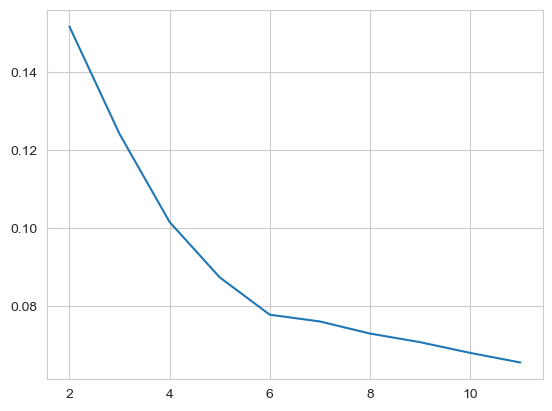

In [91]:
K = range(2, 12)
fits = []
score = []

for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state=2).fit(df_norm[vars_all])
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(df_norm[vars_all], model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

ValueError: num must be an integer with 1 <= num <= 16, not 17

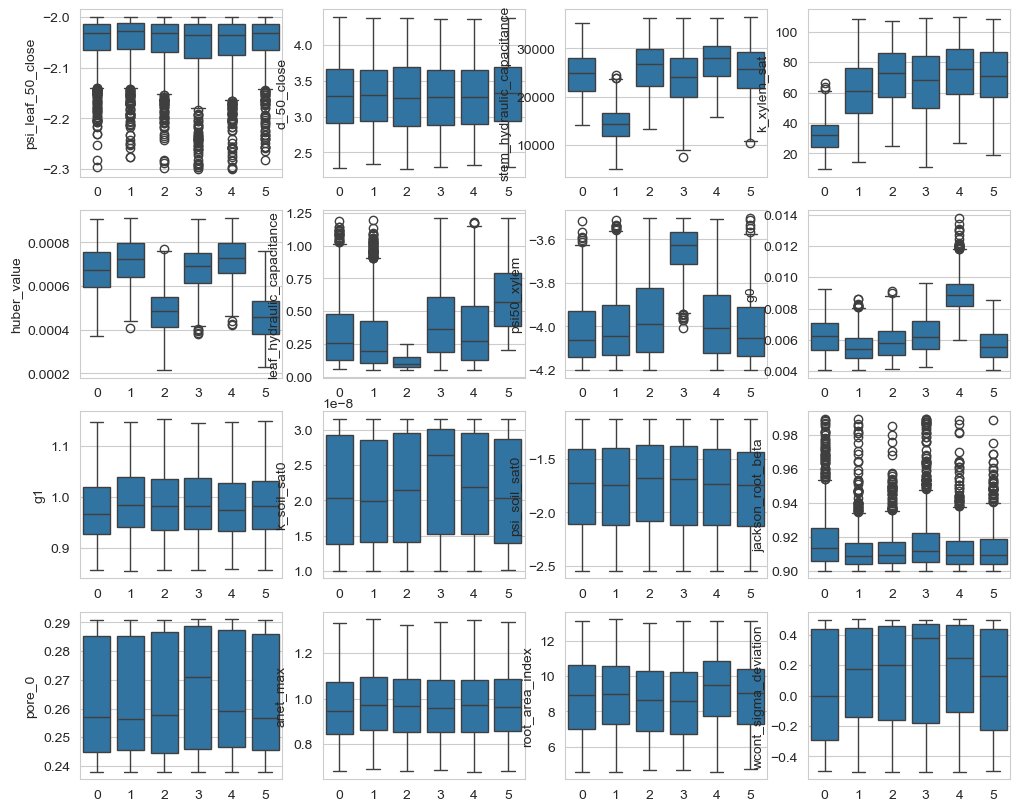

In [92]:
nclusters = 6
db = KMeans(n_clusters=nclusters, random_state=2)
db.fit(df_norm[vars_plant])
cvals = [0.0, 1]
colors = ["red", "tab:blue"]

norm = plt.Normalize(min(cvals), max(cvals))
tuples = list(zip(map(norm, cvals), colors))
import matplotlib.colors

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)
fig = plt.figure(figsize=(12, 10))
for index, var in zip(np.arange(1, len(vars) + 1), vars):
    ax = fig.add_subplot(4, 4, index)
    sns.boxplot(x=db.labels_, y=df[var], ax=ax)
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()

In [93]:
alive_means = [df_norm.loc[db.labels_ == i, 'alive'].mean() for i in range(nclusters)]
alive_means

[0.295169946332737,
 0.2794348508634223,
 0.33984375,
 0.48296007789678674,
 0.32830820770519265,
 0.2901606425702811]

In [94]:
cvals  = [0.279,  0.5]
colors = ["red","tab:blue"]

norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm, cvals), colors))
cmap2 = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

In [95]:
tuples

[(0.0, 'red'), (1.0, 'tab:blue')]

ValueError: num must be an integer with 1 <= num <= 16, not 17

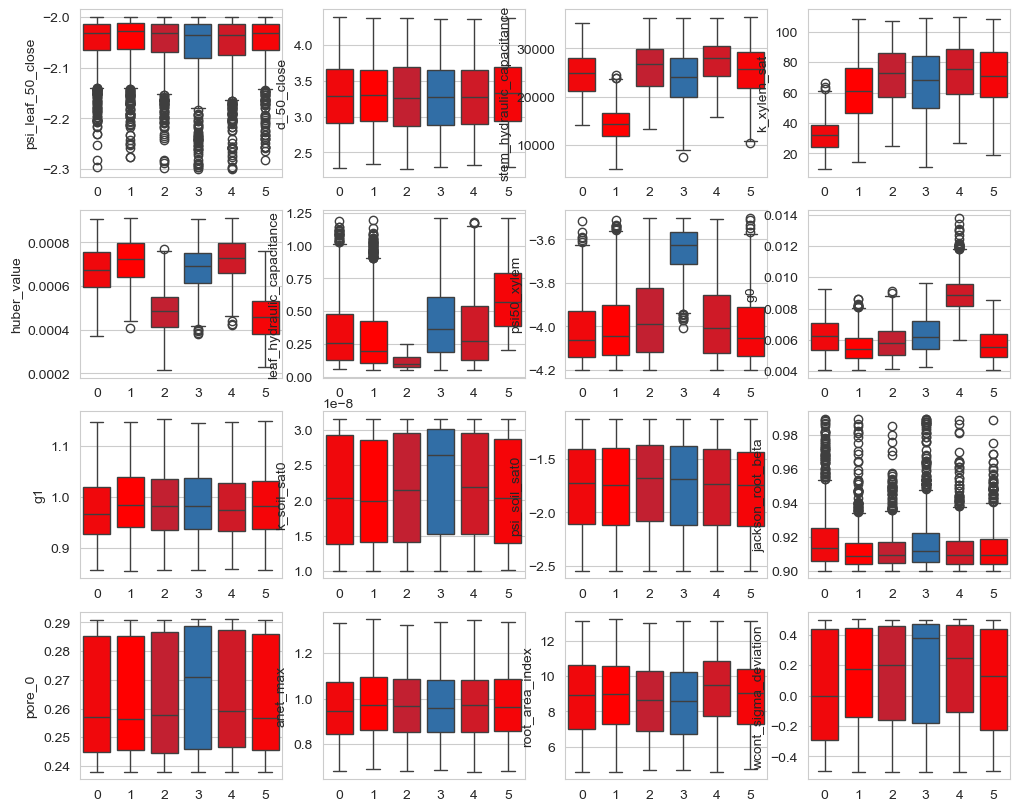

In [96]:
fig = plt.figure(figsize=(12, 10))
for index, var in zip(np.arange(1, len(vars) + 1), vars):
    ax = fig.add_subplot(4, 4, index)
    sns.boxplot(x=db.labels_, y=df[var], ax=ax)
    for i in range(nclusters):
        box = ax.patches[i]
        box.set_facecolor(cmap2(4.54* alive_means[i] - 1.273 ))
    
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()